<a href="https://colab.research.google.com/github/Trilicia/Aulas-data-science/blob/main/Desafio_Extra_An%C3%A1lise_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [5]:
df = pd.read_csv(
    f'{path}/Sample - Superstore.csv',
    encoding='latin1'
)

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Exibir as primeiras linhas do DataFrame e informações sobre os dados
print(df.head())
print(df.info())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [8]:
# Não tem valores nulos
print(df.isnull().sum())
# Não tem valores duplicados
print(df.duplicated().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [11]:
print(df.dtypes)

row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object


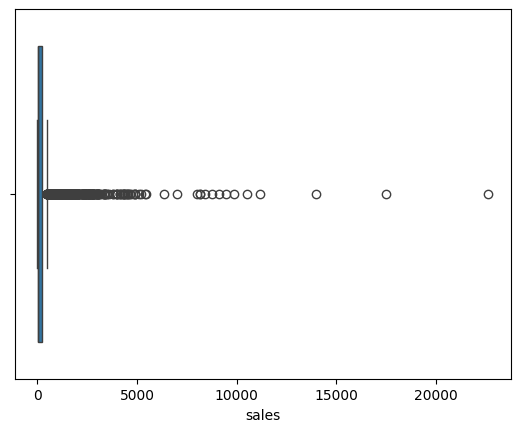

In [12]:
sns.boxplot(x=df['sales'])
plt.show()
#Foram identificados outliers na variável VENDAS, representando vendas significativamente maiores.
#Esses valores podem indicar pedidos excepcionais e foram mantidos para preservar a realidade do negócio.
# Caso queira remover os outliers, pode usar o método do IQR:
# Q1 = df['sales'].quantile(0.25)
#Q3 = df['sales'].quantile(0.75)

#IQR = Q3 - Q1

#limite_inferior = Q1 - 1.5 * IQR
#limite_superior = Q3 + 1.5 * IQR

#df_sem_outliers = df[
#    (df['sales'] >= limite_inferior) &
#    (df['sales'] <= limite_superior)
#]

In [13]:
sales_category = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(sales_category)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64


In [14]:
profit_category = (
    df.groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

print(profit_category)

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64


In [15]:
top_products = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)


product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


In [16]:
sales_region = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(sales_region)


region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64


In [17]:
negative_profit = df[df['profit'] < 0]

print(negative_profit.head())

print(df[['sales', 'profit', 'discount']].describe())



    row_id        order_id order_date  ship_date       ship_mode customer_id  \
3        4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
14      15  US-2015-118983 2015-11-22 2015-11-26  Standard Class    HP-14815   
15      16  US-2015-118983 2015-11-22 2015-11-26  Standard Class    HP-14815   
23      24  US-2017-156909 2017-07-16 2017-07-18    Second Class    SF-20065   
27      28  US-2015-150630 2015-09-17 2015-09-21  Standard Class    TB-21520   

      customer_name      segment        country             city  ...  \
3    Sean O'Donnell     Consumer  United States  Fort Lauderdale  ...   
14    Harold Pawlan  Home Office  United States       Fort Worth  ...   
15    Harold Pawlan  Home Office  United States       Fort Worth  ...   
23  Sandra Flanagan     Consumer  United States     Philadelphia  ...   
27  Tracy Blumstein     Consumer  United States     Philadelphia  ...   

   postal_code   region       product_id         category sub-category  \
3     

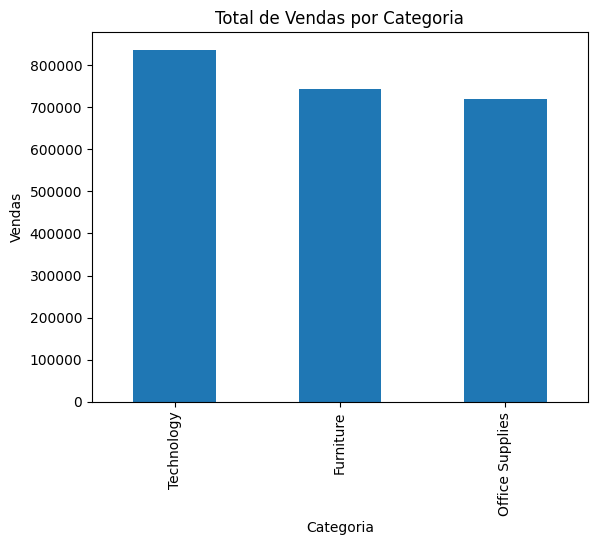

In [18]:
sales_category.plot(kind='bar')

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Vendas')
plt.show()



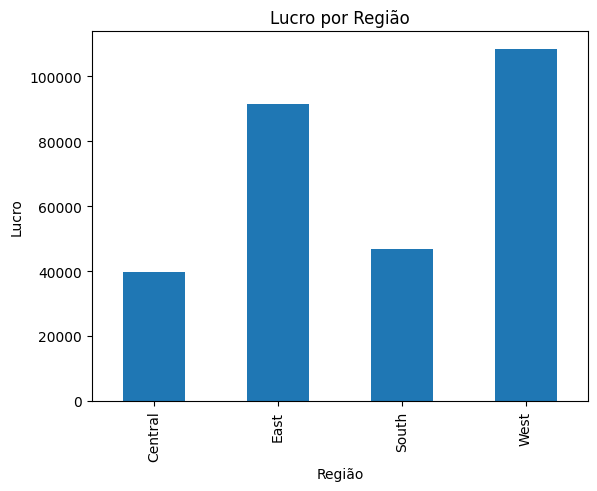

In [19]:
profit_region = df.groupby('region')['profit'].sum()

profit_region.plot(kind='bar')

plt.title('Lucro por Região')
plt.xlabel('Região')
plt.ylabel('Lucro')
plt.show()

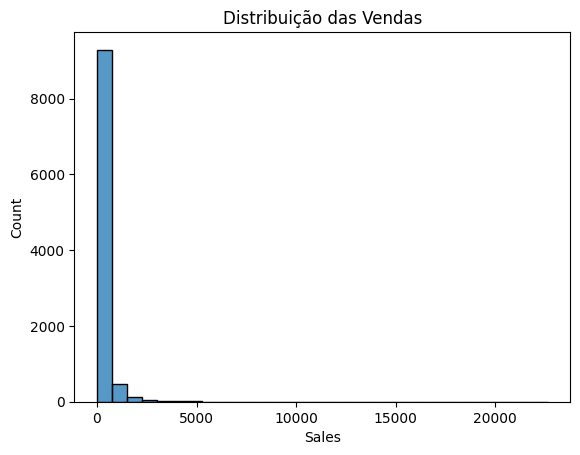

In [20]:
sns.histplot(df['sales'], bins=30)

plt.title('Distribuição das Vendas')
plt.xlabel('Sales')
plt.show()

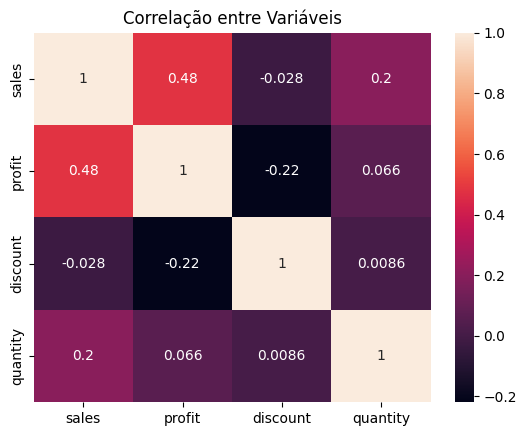

In [21]:
corr = df[['sales', 'profit', 'discount', 'quantity']].corr()

sns.heatmap(corr, annot=True)

plt.title('Correlação entre Variáveis')
plt.show()

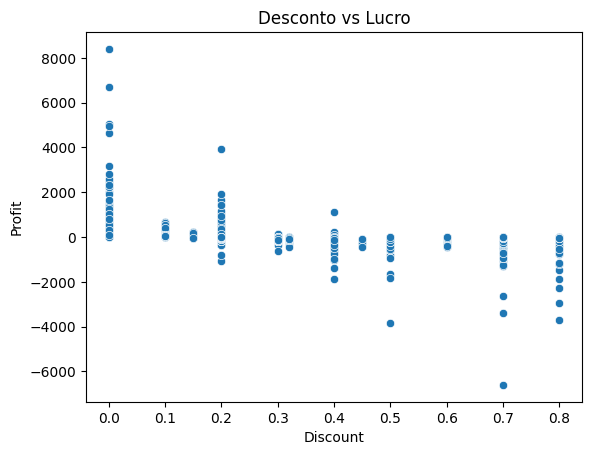

In [22]:
sns.scatterplot(
    data=df,
    x='discount',
    y='profit'
)

plt.title('Desconto vs Lucro')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()